# Wind capacity factor composites

In [18]:
import xarray as xr
import pandas as pd
import numpy as np
import geopandas

import string
letters = list(string.ascii_lowercase)

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches

import cartopy.crs as ccrs
import cartopy
cartopy.config['pre_existing_data_dir'] = '/g/data/w42/dr6273/work/data/cartopy-data/'
cartopy.config['data_dir'] = '/g/data/w42/dr6273/work/data/cartopy-data/'

In [4]:
%cd /g/data/w42/dr6273/work/hot-cloudy/

/g/data/w42/dr6273/work/hot-cloudy


In [5]:
# Get REZ shapefiles
rez_gpd = geopandas.read_file(
    "/g/data/w42/dr6273/work/projects/Aus_energy/data/resource_coded_Indicative_REZ_boundaries_2024_GIS_data.shp",
    # driver="ESRI shapefile"
)

In [6]:
# Need to convert Cartopy CRS to be compatible with GeoPandas
# https://geopandas.org/en/stable/gallery/cartopy_convert.html
# Define the CartoPy CRS object.
crs = ccrs.PlateCarree()

# This can be converted into a `proj4` string/dict compatible with GeoPandas
crs_proj4 = crs.proj4_init
rez_gpd = rez_gpd.to_crs(crs_proj4)

In [28]:
# Prepare layers
wind_gdf = rez_gpd[rez_gpd["code_2023"].isin([1, 4])]
solar_gdf = rez_gpd[rez_gpd["code_2023"] == 2]
both_gdf = rez_gpd[rez_gpd["code_2023"] == 3]

In [8]:
events = pd.read_csv(
    "data/event_dates_csi0p5_thourly90_counts.csv",
    parse_dates=True,
    index_col=0
)

In [9]:
nulls = pd.read_csv(
    "data/null_event_dates_csi0p5_thourly90_nhours7.csv",
    parse_dates=True,
    index_col=0
)

In [10]:
def get_yearly_wind(year):
    """
    Return array of wind speed for a desired year

    year: int
    """
    wind_path = "/scratch/w42/dr6273/BARRA-C2/derived/wind_speed/w100m/"
    return xr.open_zarr(
            wind_path+"w100m_BARRA-C2_20min_"+str(year)+".zarr",
            consolidated=True
        )["w100m"]

In [11]:
def get_date_wind(date):
    """
    Return array of wind speed for a single date, 1000-1600 AEST

    date: pandas Timestamp
    """
    # Open zarr store for desired year
    year = date.year
    wind = get_yearly_wind(year)

    # Select 0000-0600 UTC for date (corresponds to 1000-1600 AEST)
    end = date + pd.DateOffset(hour=6, minute=45)
    wind = wind.sel(time=slice(date, end))
    
    return wind

In [12]:
def get_all_dates_wind(dates):
    """
    Return concatenated array of wind speed for all dates

    dates: pandas DateTimeIndex
    """
    da_list = []
    for date in dates:
        wind = get_date_wind(date)
        da_list.append(wind)
    return xr.concat(da_list, dim="time")

In [13]:
def capacity_factor(W):
    """
    Computes capacity factor from wind speed data.
    
    W: wind speed (m/s)
    """
    W_0 = 3.5 # cut-in speed (m/s)
    W_r = 13 # rated speed
    W_1 = 25 # cut-out speed (m/s)
    
    # Cubic
    c_f = (W ** 3 - W_0 ** 3) / (W_r ** 3 - W_0 ** 3)
    c_f = c_f.where(W >= W_0, 0) # Set values below cut-in to zero
    c_f = c_f.where(W < W_r, 1) # Set values above rated speed to 1
    c_f = c_f.where(W < W_1, 0) # Set values above cut-off to zero
    c_f = c_f.where(W.notnull(), np.nan) # Ensure NaNs are retained
    
    return c_f

### Process for all regions

In [14]:
regions = np.unique(events["region"])

In [15]:
regions = regions[[2, 5, 4, 1]]
regions

array(['GBRI', 'GSYD', 'GMEL', 'GADE'], dtype=object)

In [16]:
# If we need to compute the composites
compute = False

In [17]:
composite_data = {}
for region in regions:
    composite_data[region] = {}

    if compute:
        # Event/null event days for region
        r_events = events[events["region"] == region]
        r_nulls = nulls[nulls["region"] == region]
    
        # Wind speed data
        r_wind_events = get_all_dates_wind(r_events.index)
        r_wind_nulls = get_all_dates_wind(r_nulls.index)
    
        # Capacity factors
        r_cf_events = capacity_factor(r_wind_events)
        r_cf_nulls = capacity_factor(r_wind_nulls)

        # Time-mean
        r_cf_events = r_cf_events.mean("time")
        r_cf_nulls = r_cf_nulls.mean("time")

        # Write to file
        r_cf_events.to_netcdf(
            "data/wind_capacity_factor_composite_events_"+region+".nc"
        )
        r_cf_nulls.to_netcdf(
            "data/wind_capacity_factor_composite_null_events_"+region+".nc"
        )

    # Read in composite data
    composite_data[region]["events"] = xr.open_mfdataset(
        "data/wind_capacity_factor_composite_events_"+region+".nc"
    )["w100m"].compute()
    composite_data[region]["nulls"] = xr.open_mfdataset(
        "data/wind_capacity_factor_composite_null_events_"+region+".nc"
    )["w100m"].compute()

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/argopy/utils/lists.py:38: UserWarning: An error occurred while loading the ERDDAP data fetcher, it will not be available !
<class 'ImportError'>
cannot import name '_quote_string_constraints' from 'erddapy.erddapy' (/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/erddapy/erddapy.py)
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/argopy/utils/lists.py:50: UserWarning: An error occurred while loading the ArgoVis data fetcher, it will not be available !
<class 'ImportError'>
cannot import name '_quote_string_constraints' from 'erddapy.erddapy' (/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/erddapy/erddapy.py)
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/argopy/utils/lists.py:66: UserWarning: An error occurred while loadi

#### Add solar composite data

In [19]:
solar_composite_data = {}
for region in regions:
    solar_composite_data[region] = {}
    
    # Read in composite data
    solar_composite_data[region]["events"] = xr.open_mfdataset(
        "data/solar_composite_events_"+region+".nc"
    ).surface_global_irradiance.compute()
    
    solar_composite_data[region]["nulls"] = xr.open_mfdataset(
        "data/solar_composite_null_events_"+region+".nc"
    ).surface_global_irradiance.compute()

In [20]:
city_coords = {
    "GBRI": [-27.47, 153.03],
    "GSYD": [-33.86, 151.20],
    "GMEL": [-37.81, 144.96],
    "GADE": [-34.56, 138.36]
}

926.3705365853659 180.82682926829267
0.026506898924708366 0.842339277267456
933.8604689092762 148.53939024390243
0.022974109277129173 0.7816556096076965
196.81180139728002 -332.80818174585414
-0.2061137706041336 0.13695760071277618

910.0283095723014 209.23210069444443
0.03425014764070511 0.7522464990615845
952.3025 113.45226430976432
0.030759889632463455 0.855487048625946
139.19697088989983 -264.2631364614474
-0.20477831363677979 0.16658106446266174

925.0052116650988 153.87657407407406
0.031224574893712997 0.7531336545944214
945.8682946708465 55.84445232466509
0.02363947033882141 0.8552451133728027
146.73571371023638 -341.30276115978614
-0.21625640988349915 0.2763283848762512

942.6994220283533 131.87086614173228
0.03240618482232094 0.7326791882514954
929.4552145922746 159.18696279844528
0.026593513786792755 0.7365875244140625
126.6481435782739 -379.0055350157493
-0.14921344816684723 0.2383435070514679



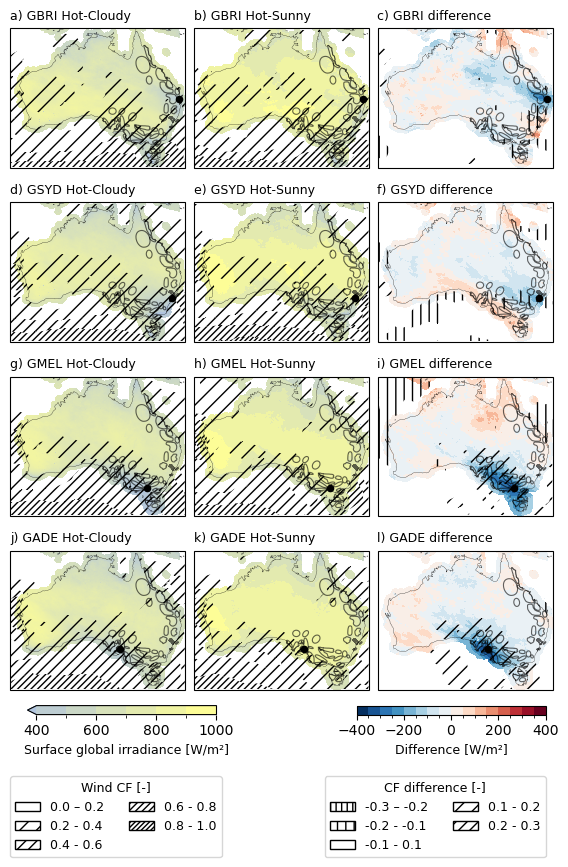

In [34]:
fig, ax = plt.subplots(4, 3,figsize=(7, 9), subplot_kw={"projection": ccrs.PlateCarree()})

grey_yellow = LinearSegmentedColormap.from_list("grey_yellow", ["lightsteelblue", "#FDFD97"])
solar_min = 400 # higher than lowest value of 55
solar_max = 1000 # higher than highest value of ~950

cf_levels = np.arange(0, 1.01, 0.2)
hatch_levels = np.arange(0, 1.01, 0.2)#[0, 0.25, 0.5, 0.75, 1.01]
hatches = ["", "//", "///", "/////", "///////"]

diff_levels = np.round(np.arange(-0.3, 0.31, 0.1), 1)
diff_levels = [i for i in diff_levels if i != 0]
diff_hatches = ["|||", "||", "", "//", "///"]

plot_count = 0
for i, r in enumerate(regions[:]):

    # ========== Hot-cloudy ===========
    # Solar
    p = solar_composite_data[r]["events"].plot(ax=ax[i,0], vmin=solar_min, vmax=solar_max, add_colorbar=False, cmap=grey_yellow, rasterized=True)
    print(solar_composite_data[r]["events"].max().values, solar_composite_data[r]["events"].min().values)
    
    # Wind
    cf_smooth = (
        composite_data[r]["events"].rolling(lat=30, lon=30, center=True)
          .mean()
    )
    print(cf_smooth.min().values, cf_smooth.max().values)

    for k in range(len(hatch_levels)-1):
        mask = (cf_smooth.values >= hatch_levels[k]) & (cf_smooth.values < hatch_levels[k+1])
        ax[i,0].contourf(cf_smooth.lon.values, cf_smooth.lat.values, mask, levels=[0.5, 1.5], hatches=[hatches[k]], colors="none")

    ax[i,0].scatter(city_coords[r][1], city_coords[r][0], color="k", marker="o", s=20)
    ax[i,0].set_title("")
    ax[i,0].set_title(letters[plot_count]+") "+r+" Hot-Cloudy", fontsize=9, loc="left")
    plot_count += 1

    # ========== Hot-sunny ===========
    # Solar
    # p = solar_composite_data[r]["nulls"].plot(ax=ax[i,1], vmin=solar_min, vmax=solar_max, add_colorbar=False, cmap=grey_yellow, rasterized=True)
    p = solar_composite_data[r]["nulls"].plot.contourf(ax=ax[i,1], levels=range(solar_min, solar_max+1, 100), add_colorbar=False, cmap=grey_yellow)
    print(solar_composite_data[r]["nulls"].max().values, solar_composite_data[r]["nulls"].min().values)

    # Wind
    cf_smooth = (
        composite_data[r]["nulls"].rolling(lat=30, lon=30, center=True)
          .mean()
    )
    print(cf_smooth.min().values, cf_smooth.max().values)

    for k in range(len(hatch_levels)-1):
        mask = (cf_smooth.values >= hatch_levels[k]) & (cf_smooth.values < hatch_levels[k+1])
        ax[i,1].contourf(cf_smooth.lon.values, cf_smooth.lat.values, mask, levels=[0.5, 1.5], hatches=[hatches[k]], colors="none")

    ax[i,1].scatter(city_coords[r][1], city_coords[r][0], color="k", marker="o", s=20)
    ax[i,1].set_title("")
    ax[i,1].set_title(letters[plot_count]+") "+r+" Hot-Sunny", fontsize=9, loc="left")
    plot_count += 1

    # ========== Difference ===========
    # Solar
    diff = solar_composite_data[r]["events"] - solar_composite_data[r]["nulls"]
    # p_diff = diff.plot(ax=ax[i,2], vmin=-400, vmax=400, cmap="RdBu_r", add_colorbar=False, rasterized=True)
    p_diff = diff.plot.contourf(ax=ax[i,2], levels=range(-400, 401, 50), cmap="RdBu_r", add_colorbar=False)
    print(diff.max().values, diff.min().values)
    
    # Wind
    diff_s = composite_data[r]["events"] - composite_data[r]["nulls"]
    cf_smooth = (
        diff_s.rolling(lat=30, lon=30, center=True)
          .mean()
    )
    print(cf_smooth.min().values, cf_smooth.max().values)
    
    for k in range(len(diff_levels)-1):
        mask = (cf_smooth.values >= diff_levels[k]) & (cf_smooth.values < diff_levels[k+1])
        ax[i,2].contourf(cf_smooth.lon.values, cf_smooth.lat.values, mask, levels=[0.5, 1.5], hatches=[diff_hatches[k]], colors="none")

    ax[i,2].scatter(city_coords[r][1], city_coords[r][0], color="k", marker="o", s=20)
    ax[i,2].set_title("")
    ax[i,2].set_title(letters[plot_count]+") "+r+" difference", fontsize=9, loc="left")
    plot_count += 1

    print()

for a in ax.flatten():
    a.add_feature(cartopy.feature.OCEAN, facecolor="white", zorder=0)
    a.coastlines(lw=.2)
    a.set_xlabel("")
    a.set_xticklabels([])
    a.set_ylabel("")
    a.set_yticklabels([])
    a.set_extent([111, 154.5, -10, -42.5])

    rez_gpd.plot(
        ax=a,
        alpha=0.6,
        facecolor="none",
        edgecolor="k",
        linewidth=.8,
        rasterized=True,
        # label="Wind",
    )

    # solar_gdf.plot(
    #     ax=a,
    #     alpha=0.6,
    #     facecolor="none",
    #     edgecolor="tab:orange",
    #     linewidth=0.3,
    #     rasterized=True,
    #     label="Solar",
    # )

    # both_gdf.plot(
    #     ax=a,
    #     alpha=0.6,
    #     facecolor="none",
    #     edgecolor="tab:blue",
    #     linewidth=0.3,
    #     rasterized=True,
    #     label="Wind and solar",
    # )

plt.subplots_adjust(hspace=0.03)

# Solar colorbars
cax1 = fig.add_axes([0.15, 0.1, 0.27, 0.01])
cbar1 = fig.colorbar(p, cax=cax1, ticks=np.arange(400, 1001, 200), orientation="horizontal", extend="min")
cbar1.ax.set_xlabel(r"Surface global irradiance [W/m²]", fontsize=9)

cax2 = fig.add_axes([0.62, 0.1, 0.27, 0.01])
cbar2 = fig.colorbar(p_diff, cax=cax2, ticks=np.arange(-400, 401, 200), orientation="horizontal")
cbar2.ax.set_xlabel(r"Difference [W/m²]", fontsize=9)

# Wind cf hatch legend
hatch_labels = [
    "0.0 – 0.2",
    "0.2 - 0.4",
    "0.4 - 0.6",
    "0.6 - 0.8",
    "0.8 - 1.0"
]

hatch_handles = [
    mpatches.Patch(facecolor='white', hatch=hatches[i], label=hatch_labels[i], edgecolor='black')
    for i in range(5)
]

ax[3,0].legend(
    handles=hatch_handles,
    title="Wind CF [-]",
    loc=(0, -1.2),
    frameon=True,
    fontsize=9,
    title_fontsize=9,
    ncols=2
)

# Wind cf difference legend

hatch_labels = [
    "-0.3 – -0.2",
    "-0.2 - -0.1",
    "-0.1 - 0.1",
    "0.1 - 0.2",
    "0.2 - 0.3"
]

hatch_handles = [
    mpatches.Patch(facecolor='white', hatch=diff_hatches[i], label=hatch_labels[i], edgecolor='black')
    for i in range(5)
]

ax[3,2].legend(
    handles=hatch_handles,
    title="CF difference [-]",
    loc=(-0.3, -1.2),
    frameon=True,
    fontsize=9,
    title_fontsize=9,
    ncols=2
)

plt.subplots_adjust(hspace=0.02, wspace=0.05)

plt.savefig("figs/energy_resource_composites.png", format="png", dpi=400, bbox_inches="tight")